<a href="https://colab.research.google.com/github/vkhanht1/tensorflow-fashion-mnist/blob/main/fashion_mnist_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print({keras.__version__})

{'3.13.2'}


In [111]:
import matplotlib.pyplot as plt
import numpy as np

import random

# 1. Load Data

In [112]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [113]:
type(X_train), type(y_train)

(numpy.ndarray, numpy.ndarray)

In [114]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [115]:
X_train.dtype, y_train.dtype

(dtype('uint8'), dtype('uint8'))

In [116]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_nums = len(class_names)
print(class_nums)

10


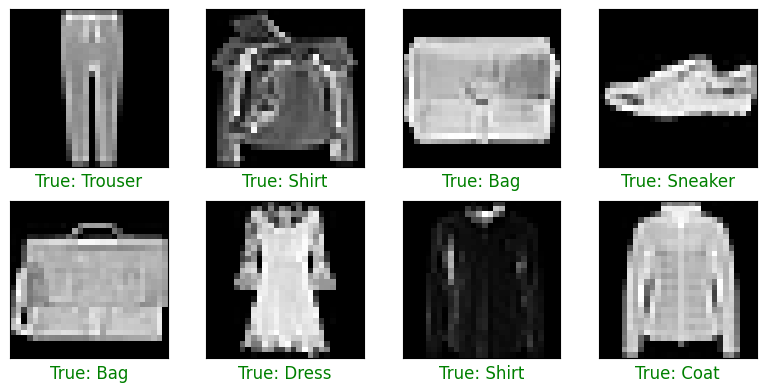

In [147]:
from typing import Optional

def plot_data(x_data: np.ndarray, y_data: np.ndarray, y_proba: Optional[np.ndarray] = None) -> None:
  nrows, ncols = 2 ,4
  fig, axes = plt.subplots(nrows, ncols, figsize=(8, 4))

  len_x = x_data.shape[0]
  for idx in range(nrows*ncols):
    ax = axes[idx // ncols, idx % ncols]

    img_idx = random.randint(0, len_x)

    ax.imshow(x_data[img_idx], cmap='gray')
    ax.set(xticks=[], yticks=[])
    color= 'green'
    true_label_str = f"True: {class_names[y_data[img_idx]]}"

    if y_proba is not None:
      predicted_idx = np.argmax(y_proba[img_idx])
      predicted_label = class_names[predicted_idx]
      color = 'red' if predicted_idx != y_data[img_idx] else color
      predicted_label_str = f"\nPredicted: {predicted_label}"

    img_titl = true_label_str if y_proba is None else true_label_str + predicted_label_str
    ax.set_xlabel(img_titl, color=color, fontsize=12)

  plt.tight_layout()
  plt.show()

plot_data(X_train, y_train)

IMAGE PRE-PROCESSING

In [118]:
# convert to float32 & scale images to the [0, 1] range for training
X_train = X_train.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255

In [119]:
X_test.shape, X_test.dtype

((10000, 28, 28), dtype('float32'))

In [120]:
# make sure images have shape (60000, 28, 28) => (60000, 28, 28, 1)

X_train = np.expand_dims(X_train, axis=-1)

In [121]:
X_train.shape

(60000, 28, 28, 1)

In [122]:
X_test = np.expand_dims(X_test, axis=-1)

In [123]:
y_train_label = keras.utils.to_categorical(y_train,class_nums)
y_test_label = keras.utils.to_categorical(y_test,class_nums)

In [124]:
y_train[0], y_train_label[0]

(np.uint8(9), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))

# 3. Network Architecture

In [125]:
input_shape = (28, 28, 1)

In [126]:
model = keras.models.Sequential([
    layers.Flatten(input_shape=input_shape),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(class_nums, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [128]:
epochs = 10
batch_size = 256
history = model.fit(X_train, y_train_label,
          epochs=epochs,
          batch_size=batch_size,
          validation_split=0.1
          )

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7744 - loss: 0.6276 - val_accuracy: 0.8098 - val_loss: 0.4917
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8467 - loss: 0.4186 - val_accuracy: 0.8638 - val_loss: 0.3705
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8656 - loss: 0.3620 - val_accuracy: 0.8723 - val_loss: 0.3515
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8759 - loss: 0.3314 - val_accuracy: 0.8748 - val_loss: 0.3370
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8861 - loss: 0.3072 - val_accuracy: 0.8813 - val_loss: 0.3208
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8914 - loss: 0.2895 - val_accuracy: 0.8838 - val_loss: 0.3172
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8976 - loss: 0.2729 - val_accuracy: 0.8832 - val_loss: 0.3176
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9017 - loss: 0.2605 - val_accu

In [129]:
history_dict = history.history

In [130]:
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [131]:
train_loss, val_loss = history_dict['loss'], history_dict['val_loss']
train_acc, val_acc = history_dict['accuracy'], history_dict['val_accuracy']

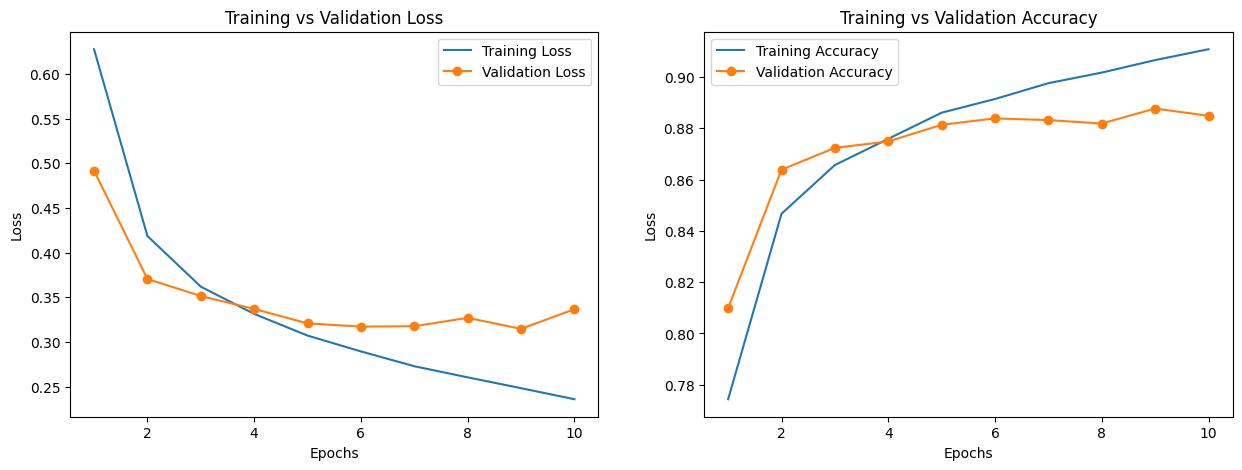

In [138]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
epoch_runs = [i+1 for i in range(epochs)]

ax1.plot(epoch_runs, train_loss, label='Training Loss')
ax1.plot(epoch_runs, val_loss, label='Validation Loss', marker='o')
ax1.set(title='Training vs Validation Loss', xlabel='Epochs', ylabel='Loss')
ax1.legend()

ax2.plot(epoch_runs, train_acc, label='Training Accuracy')
ax2.plot(epoch_runs, val_acc, label='Validation Accuracy', marker='o')
ax2.set(title='Training vs Validation Accuracy', xlabel='Epochs', ylabel='Loss')
ax2.legend()

plt.show()

# 4.Model Evalution

In [140]:
score = model.evaluate(X_test, y_test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8865 - loss: 0.3430


In [141]:
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

Test Loss: 0.3430
Test Accuracy: 0.8865


# 5.Prediction

In [142]:
X_sample = X_test[:3]
y_proba = model.predict(X_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [143]:
y_proba.round(3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.004, 0.   ,
        0.996],
       [0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]], dtype=float32)

In [144]:
predictions = np.argmax(y_proba, axis=1)

In [145]:
[class_names[pred] for pred in predictions]

['Ankle boot', 'Pullover', 'Trouser']

In [148]:
y_proba = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


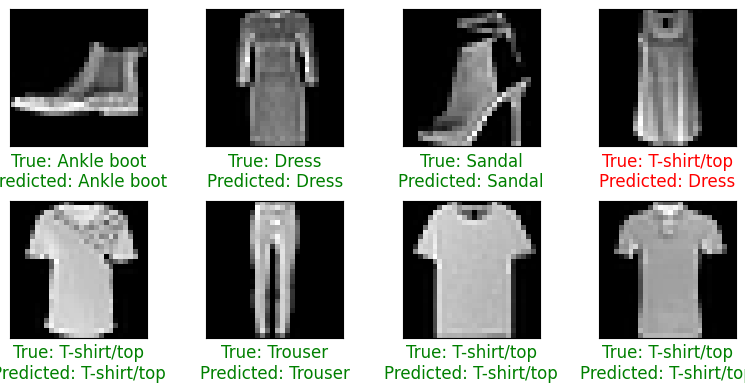

In [153]:
plot_data(X_test, y_test, y_proba)